Sales: (30490, 1947)
Calendar: (1969, 14)
Prices: (6841121, 4)

Sales columns:
['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd_1', 'd_2', 'd_3', 'd_4', 'd_5', 'd_6', 'd_7', 'd_8', 'd_9', 'd_10', 'd_11', 'd_12', 'd_13', 'd_14', 'd_15', 'd_16', 'd_17', 'd_18', 'd_19', 'd_20', 'd_21', 'd_22', 'd_23', 'd_24', 'd_25', 'd_26', 'd_27', 'd_28', 'd_29', 'd_30', 'd_31', 'd_32', 'd_33', 'd_34', 'd_35', 'd_36', 'd_37', 'd_38', 'd_39', 'd_40', 'd_41', 'd_42', 'd_43', 'd_44', 'd_45', 'd_46', 'd_47', 'd_48', 'd_49', 'd_50', 'd_51', 'd_52', 'd_53', 'd_54', 'd_55', 'd_56', 'd_57', 'd_58', 'd_59', 'd_60', 'd_61', 'd_62', 'd_63', 'd_64', 'd_65', 'd_66', 'd_67', 'd_68', 'd_69', 'd_70', 'd_71', 'd_72', 'd_73', 'd_74', 'd_75', 'd_76', 'd_77', 'd_78', 'd_79', 'd_80', 'd_81', 'd_82', 'd_83', 'd_84', 'd_85', 'd_86', 'd_87', 'd_88', 'd_89', 'd_90', 'd_91', 'd_92', 'd_93', 'd_94', 'd_95', 'd_96', 'd_97', 'd_98', 'd_99', 'd_100', 'd_101', 'd_102', 'd_103', 'd_104', 'd_105', 'd_106', 'd_107', 'd_

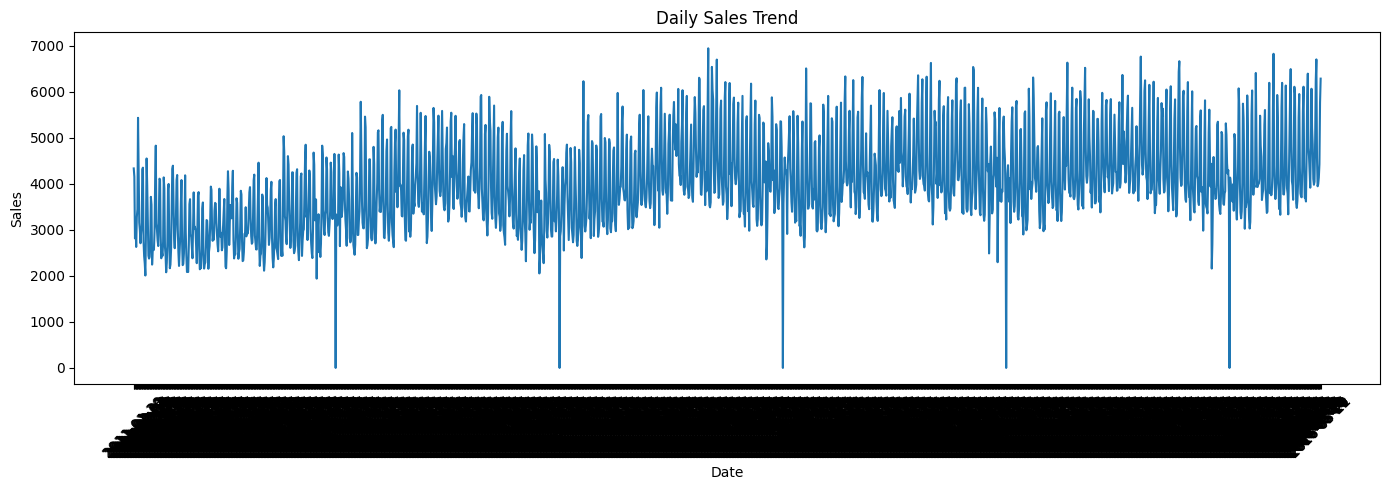

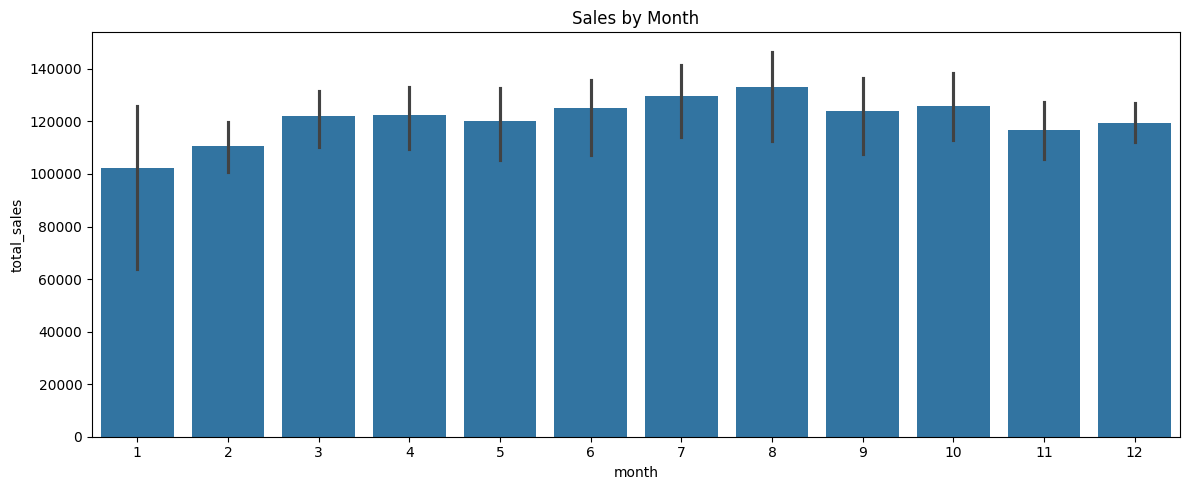


Sales by Weekday:
shape: (7, 2)
┌───────────┬─────────────┐
│ weekday   ┆ total_sales │
│ ---       ┆ ---         │
│ str       ┆ i64         │
╞═══════════╪═════════════╡
│ Thursday  ┆ 932910      │
│ Wednesday ┆ 922296      │
│ Tuesday   ┆ 947531      │
│ Monday    ┆ 1070720     │
│ Saturday  ┆ 1411710     │
│ Sunday    ┆ 1430155     │
│ Friday    ┆ 1116926     │
└───────────┴─────────────┘

Sales by Category:
shape: (3, 2)
┌───────────┬─────────────┐
│ cat_id    ┆ total_sales │
│ ---       ┆ ---         │
│ str       ┆ i64         │
╞═══════════╪═════════════╡
│ FOODS     ┆ 5471661     │
│ HOUSEHOLD ┆ 1468504     │
│ HOBBIES   ┆ 892083      │
└───────────┴─────────────┘


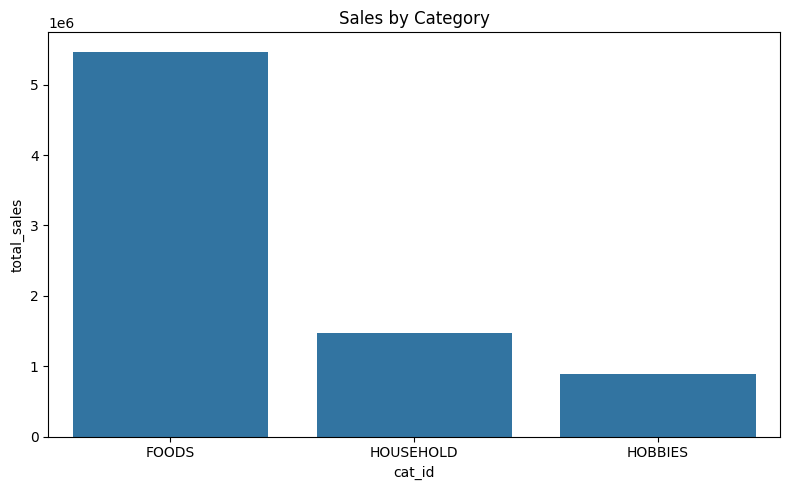


Top Departments:
shape: (7, 2)
┌─────────────┬─────────────┐
│ dept_id     ┆ total_sales │
│ ---         ┆ ---         │
│ str         ┆ i64         │
╞═════════════╪═════════════╡
│ FOODS_3     ┆ 3993834     │
│ HOUSEHOLD_1 ┆ 1121388     │
│ FOODS_2     ┆ 900391      │
│ HOBBIES_1   ┆ 835578      │
│ FOODS_1     ┆ 577436      │
│ HOUSEHOLD_2 ┆ 347116      │
│ HOBBIES_2   ┆ 56505       │
└─────────────┴─────────────┘

Sales by Event Type:
shape: (4, 2)
┌──────────────┬─────────────┐
│ event_type_1 ┆ total_sales │
│ ---          ┆ ---         │
│ str          ┆ i64         │
╞══════════════╪═════════════╡
│ Religious    ┆ 215275      │
│ National     ┆ 176950      │
│ Cultural     ┆ 146138      │
│ Sporting     ┆ 64983       │
└──────────────┴─────────────┘

========== EDA SUMMARY ==========
Store analysed: CA_1
Products: 3049
Departments: 7
Categories: 3

Highest Sales Category:
shape: (1, 2)
┌────────┬─────────────┐
│ cat_id ┆ total_sales │
│ ---    ┆ ---         │
│ str    ┆ i64    

In [1]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 1. LOAD DATA
# =========================

sales = pl.read_csv(
    r"C:\Users\Nikesh\Enterprise-Demand-Forecasting\data\raw\sales_train_evaluation.csv"
)

calendar = pl.read_csv(
    r"C:\Users\Nikesh\Enterprise-Demand-Forecasting\data\raw\calendar.csv"
)

prices = pl.read_csv(
    r"C:\Users\Nikesh\Enterprise-Demand-Forecasting\data\raw\sell_prices.csv"
)

print("Sales:", sales.shape)
print("Calendar:", calendar.shape)
print("Prices:", prices.shape)


# =========================
# 2. BASIC DATA OVERVIEW
# =========================

print("\nSales columns:")
print(sales.columns)

print("\nCalendar columns:")
print(calendar.columns)

print("\nPrice columns:")
print(prices.columns)

print("\nMissing values:")
print("Sales:", sales.null_count().sum_horizontal().sum())
print("Calendar:", calendar.null_count().sum_horizontal().sum())
print("Prices:", prices.null_count().sum())


# =========================
# 3. DATASET INFORMATION
# =========================

print("\nUnique Products:", sales["item_id"].n_unique())
print("Unique Stores:", sales["store_id"].n_unique())
print("Unique Departments:", sales["dept_id"].n_unique())
print("Unique Categories:", sales["cat_id"].n_unique())
print("Unique States:", sales["state_id"].n_unique())


# =========================
# 4. SALES DATA → LONG FORMAT
# =========================
# Use only CA_1 for analysis to avoid memory issues.

ca_sales = sales.filter(
    pl.col("store_id") == "CA_1"
)

day_cols = [c for c in ca_sales.columns if c.startswith("d_")]

long_sales = ca_sales.unpivot(
    index=["item_id", "dept_id", "cat_id", "store_id", "state_id"],
    on=day_cols,
    variable_name="d",
    value_name="sales"
)

# Join calendar
long_sales = long_sales.join(
    calendar.select([
        "d", "date", "wm_yr_wk",
        "weekday", "month", "year",
        "event_name_1", "event_type_1"
    ]),
    on="d",
    how="left"
)

print("\nLong Sales Shape:", long_sales.shape)


# =========================
# 5. DAILY SALES ANALYSIS
# =========================

daily_sales = (
    long_sales
    .group_by("date")
    .agg(
        pl.col("sales").sum().alias("total_sales")
    )
    .sort("date")
)

daily_pd = daily_sales.to_pandas()

plt.figure(figsize=(14, 5))
plt.plot(
    daily_pd["date"],
    daily_pd["total_sales"]
)
plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# =========================
# 6. MONTHLY SALES
# =========================

monthly_sales = (
    long_sales
    .group_by(["year", "month"])
    .agg(
        pl.col("sales").sum().alias("total_sales")
    )
    .sort(["year", "month"])
)

monthly_pd = monthly_sales.to_pandas()

plt.figure(figsize=(12, 5))
sns.barplot(
    data=monthly_pd,
    x="month",
    y="total_sales"
)
plt.title("Sales by Month")
plt.tight_layout()
plt.show()


# =========================
# 7. SALES BY WEEKDAY
# =========================

weekday_sales = (
    long_sales
    .group_by("weekday")
    .agg(
        pl.col("sales").sum().alias("total_sales")
    )
)

print("\nSales by Weekday:")
print(weekday_sales)


# =========================
# 8. SALES BY CATEGORY
# =========================

category_sales = (
    long_sales
    .group_by("cat_id")
    .agg(
        pl.col("sales").sum().alias("total_sales")
    )
    .sort("total_sales", descending=True)
)

print("\nSales by Category:")
print(category_sales)

category_pd = category_sales.to_pandas()

plt.figure(figsize=(8, 5))
sns.barplot(
    data=category_pd,
    x="cat_id",
    y="total_sales"
)
plt.title("Sales by Category")
plt.tight_layout()
plt.show()


# =========================
# 9. SALES BY DEPARTMENT
# =========================

dept_sales = (
    long_sales
    .group_by("dept_id")
    .agg(
        pl.col("sales").sum().alias("total_sales")
    )
    .sort("total_sales", descending=True)
)

print("\nTop Departments:")
print(dept_sales.head(10))


# =========================
# 10. EVENT ANALYSIS
# =========================

event_sales = (
    long_sales
    .filter(pl.col("event_type_1").is_not_null())
    .group_by("event_type_1")
    .agg(
        pl.col("sales").sum().alias("total_sales")
    )
    .sort("total_sales", descending=True)
)

print("\nSales by Event Type:")
print(event_sales)


# =========================
# 11. FINAL EDA SUMMARY
# =========================

print("\n========== EDA SUMMARY ==========")
print("Store analysed: CA_1")
print("Products:", ca_sales["item_id"].n_unique())
print("Departments:", ca_sales["dept_id"].n_unique())
print("Categories:", ca_sales["cat_id"].n_unique())

print("\nHighest Sales Category:")
print(category_sales.head(1))

print("\nHighest Sales Department:")
print(dept_sales.head(1))

print("\nEDA completed successfully!")